# Compression Apporaches for Blendshapes

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

from src.data import load_clip, extract_tracks, get_joint_idx

In [27]:
CLIP_IDX = 481

### Summary

- **Intense uniqueness problem**, should group blendshapes by unique values and times.
- No staticity problem (at least from tested clip), look like it is already handled by keyframing.
    - To Try: Completely delete the static tracks, ThreeJS should be able to handle it, should provide moderate size reduction.
- Moderate colinearity problem, some amount of colinear decimation should help reduce the size, but not as much. Force too much decimation may effect the animation too much.
- **Quantization is a must**, providing impressive compression and loss.
    - Heavy quantization on values is tangible, most values have narrow range -> low quantization loss.
    - To Consider: Hybrid compression rate: 8-bit for values, 16-bit for times, should provide almost no loss.
- Frame encoding as an alternative for times quantization (especially for known maximum number of keyframes/duration).
    - 120 Fps gives about the same quality as 16-bit quantization with same number of bits needed for clip with less than 9 minutes duration.

---
## Load Test Clip

In [28]:
original_clip = load_clip(f"data/json/clip_{CLIP_IDX}.json")

original_tracks = original_clip["animationClip"]["tracks"]
number_tracks = extract_tracks(original_tracks, type="number")
quater_tracks = extract_tracks(original_tracks, type="quaternion")

In [29]:
temp = deepcopy(original_clip)
temp["animationClip"]["tracks"] = "tracks"
temp

{'_id': {'$oid': '67cc083cfd081b0548566508'},
 'animationClip': {'name': '-1741424699845',
  'duration': 7.153490000000602,
  'tracks': 'tracks',
  'uuid': '86c11ac9-14a8-4174-a71b-092ee59ed729',
  'blendMode': 2500},
 'recordDate': 1741424699846}

---
## Uniqueness

In [30]:
unique_data = []

for track in number_tracks:
    name = track["name"]
    times = track["times"]
    values = track["values"]

    if not unique_data:
        unique_data.append(dict(
            names=[name],
            times=times, 
            values=values,
        ))

    else:
        dup = False
        for data in unique_data:
            if len(times) == len(data["times"]):
                if np.allclose(times, data["times"]) & np.allclose(values, data["values"]):
                    data["names"].append(name)
                    dup = True
        
        if not dup:
            unique_data.append(dict(
                names=[name],
                times=times, 
                values=values,
            ))

In [31]:
print(f"num tracks: {len(number_tracks)}")
print(f"num unique tracks: {len(unique_data)}")

num tracks: 129
num unique tracks: 51


In [32]:
for data in unique_data:
    print(f"{len(data["names"])} {data["names"]}")

2 ['Alex_body_1.morphTargetInfluences[0]', 'Alex_body_2.morphTargetInfluences[0]']
4 ['Alex_body_1.morphTargetInfluences[1]', 'Alex_body_2.morphTargetInfluences[1]', 'Alex_iris_left_1.morphTargetInfluences[0]', 'Alex_iris_left_2.morphTargetInfluences[0]']
4 ['Alex_body_1.morphTargetInfluences[2]', 'Alex_body_2.morphTargetInfluences[2]', 'Alex_iris_left_1.morphTargetInfluences[4]', 'Alex_iris_left_2.morphTargetInfluences[4]']
6 ['Alex_body_1.morphTargetInfluences[3]', 'Alex_body_1.morphTargetInfluences[15]', 'Alex_body_2.morphTargetInfluences[3]', 'Alex_body_2.morphTargetInfluences[15]', 'Alex_iris_left_1.morphTargetInfluences[6]', 'Alex_iris_left_2.morphTargetInfluences[6]']
4 ['Alex_body_1.morphTargetInfluences[4]', 'Alex_body_2.morphTargetInfluences[4]', 'Alex_iris_left_1.morphTargetInfluences[2]', 'Alex_iris_left_2.morphTargetInfluences[2]']
2 ['Alex_body_1.morphTargetInfluences[5]', 'Alex_body_2.morphTargetInfluences[5]']
2 ['Alex_body_1.morphTargetInfluences[6]', 'Alex_body_2.morp

In [33]:
inspect_track = original_tracks[get_joint_idx(original_clip, name="Alex_body_1.morphTargetInfluences[44]")]
print(inspect_track)

{'name': 'Alex_body_1.morphTargetInfluences[44]', 'times': [0, 0.36344999074935913, 0.3966499865055084, 0.4293699860572815, 0.4625700116157532, 0.4959999918937683, 0.5284900069236755, 0.5616899728775024, 0.5944100022315979, 0.6276100277900696, 0.6620000004768372, 0.6945000290870667, 0.7277100086212158, 0.7609999775886536, 0.7936300039291382, 0.8270000219345093, 0.8600000143051147, 0.8927500247955322, 0.9259999990463257, 0.9586600065231323, 0.9919999837875366, 1.024999976158142, 1.0579999685287476, 1.090999960899353, 1.1239999532699585, 1.156999945640564, 1.190000057220459, 1.2233099937438965, 1.25600004196167, 1.2899999618530273, 1.3229999542236328, 1.3559999465942383, 1.3893300294876099, 1.4220000505447388, 1.4552500247955322, 1.488450050354004, 1.5210000276565552, 1.5543700456619263, 1.5875699520111084, 1.6202900409698486, 1.6534899473190308, 1.6859999895095825, 1.7194099426269531, 1.7526099681854248, 1.7853200435638428, 1.8185299634933472, 1.8517299890518188, 1.8844499588012695, 1.9

---
## Staticity

In [34]:
for i, data in enumerate(unique_data):
    names = data["names"]
    times = data["times"]
    values = data["values"]
    
    length = len(values)
    max_val = np.max(values)
    min_val = np.min(values)

    print(f"group {i:<3} |  members = {len(names):<3} | len = {length:<5} |  minmax = ({min_val:.6f}, {max_val:.6f})  |  range = {max_val - min_val:.6f}")

group 0   |  members = 2   | len = 25    |  minmax = (0.000000, 0.944095)  |  range = 0.944095
group 1   |  members = 4   | len = 109   |  minmax = (0.000000, 0.255272)  |  range = 0.255272
group 2   |  members = 4   | len = 216   |  minmax = (0.001770, 0.170417)  |  range = 0.168647
group 3   |  members = 6   | len = 2     |  minmax = (0.000000, 0.000000)  |  range = 0.000000
group 4   |  members = 4   | len = 133   |  minmax = (0.000000, 0.213143)  |  range = 0.213143
group 5   |  members = 2   | len = 216   |  minmax = (0.057918, 0.321153)  |  range = 0.263234
group 6   |  members = 2   | len = 205   |  minmax = (0.000000, 0.587900)  |  range = 0.587900
group 7   |  members = 2   | len = 23    |  minmax = (0.000000, 0.943713)  |  range = 0.943713
group 8   |  members = 4   | len = 109   |  minmax = (0.000000, 0.255643)  |  range = 0.255643
group 9   |  members = 4   | len = 152   |  minmax = (0.000000, 0.119380)  |  range = 0.119380
group 10  |  members = 4   | len = 81    |  minmax

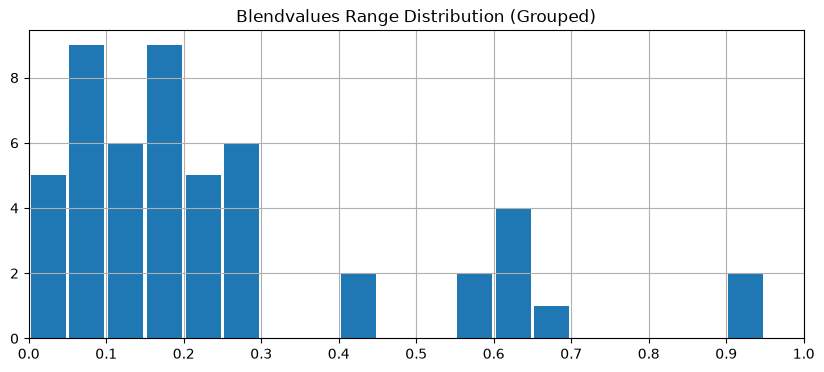

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))

ranges = [np.max(data["values"]) - np.min(data["values"]) for data in unique_data]
ax.hist(ranges, bins=np.linspace(0, 1, 21), rwidth=0.9)
ax.set_title("Blendvalues Range Distribution (Grouped)")
ax.set_xbound(0.0, 1.0)
ax.set_xticks(np.linspace(0, 1, 11))
ax.grid()
plt.show()

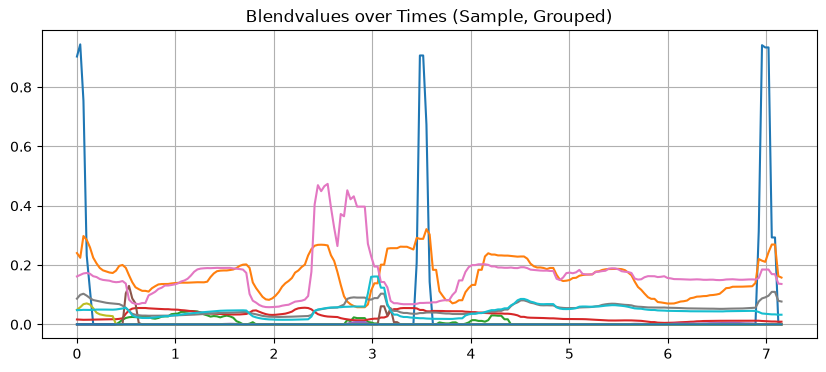

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))

for i, data in enumerate(unique_data[::5]):
    names = data["names"]
    times = data["times"]
    values = data["values"]
    ax.plot(times, values)

ax.set_title("Blendvalues over Times (Sample, Grouped)")
ax.grid()
plt.show()

---
## Colinearity

In [37]:
def colinear_decimation(times, values, threshold=1e-3):
    vecs = np.stack([times, values], axis=1)
    i = 1
    while i < vecs.shape[0] - 1:
            v = vecs[i + 1] - vecs[i - 1]
            w = vecs[i] - vecs[i - 1]
            projection_weight = np.dot(w, v) / np.linalg.norm(v) ** 2
            perpendicular_vec = w - projection_weight * v
            perpendicular_dist = np.linalg.norm(perpendicular_vec)

            if perpendicular_dist <= threshold:
                vecs = np.delete(vecs, i, axis=0)
            else:
                i += 1
            
    return vecs

original 25
decimated 23


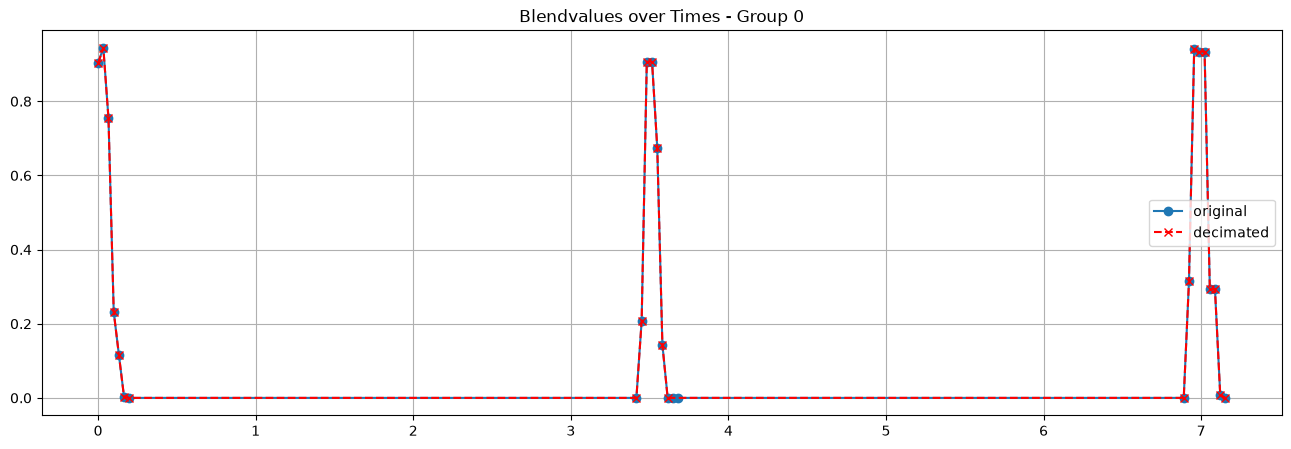

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0
test_cld = colinear_decimation(unique_data[group_idx]["times"], unique_data[group_idx]["values"], threshold=1e-4)

print("original", len(unique_data[group_idx]["values"]))
print("decimated", test_cld.shape[0])

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], 'o-', label="original")
ax.plot(test_cld[:, 0], test_cld[:, 1], 'rx--', label="decimated")

ax.set_title(f"Blendvalues over Times - Group {group_idx}")
ax.legend()
ax.grid()
plt.show()

---
## Quantization

In [39]:
def quantize(data, q_type=np.uint8):
    data_min, data_max = np.min(data), np.max(data)
    num_bits = np.dtype(q_type).itemsize * 8

    scale = (data_max - data_min) / (2 ** num_bits - 1)
    zero  = np.round(-data_min / scale)
    codes = np.round(data / scale) + zero

    return codes.astype(q_type), scale, zero

def dequantize(codes, scale, zero):
    return scale * (codes - zero)

In [40]:
codes, scale, zero = quantize(original_tracks[2]["values"])
codes

array([116,  87, 149, 155, 147, 158, 160, 156, 168, 167, 168, 171, 184,
       198, 211, 219, 224, 225, 224, 223, 225, 225, 228, 218, 216, 220,
       226, 228, 228, 238, 240, 242, 250, 250, 251, 255, 254, 253, 247,
       238, 232, 225, 228, 227, 221, 227, 230, 226, 219, 202, 195, 187,
       185, 190, 199, 187, 181, 168, 179, 169, 158, 131, 125, 120, 129,
       136, 135, 139, 135, 144, 149, 153, 166, 161, 158, 160, 162, 156,
       153, 154, 150, 162, 182, 212, 206, 226, 222, 222, 201, 198, 193,
       193, 185, 185, 146, 157, 158, 158, 153, 156, 156, 158, 157, 113,
       125, 125, 118, 132, 162, 162, 201, 198, 195, 195, 199, 199, 189,
       189, 192, 198, 209, 209, 204, 204, 200, 207, 231, 231, 230, 230,
       211, 211, 176, 144, 123, 111, 111, 112, 117, 120, 119, 111, 102,
        82,  82,  82,  97,  97,  90,  84,  81,  84,  83,  84,  92,  96,
       106, 111, 113, 114, 115, 115, 116, 111, 111, 108, 104, 104, 101,
        97,  69,  68,  63,  51,  64,  61,  61,  61,  61,  57,  4

In [41]:
dequantize(codes, scale, zero)

array([0.07870214, 0.05952263, 0.10052711, 0.10449528, 0.09920438,
       0.10647937, 0.10780209, 0.10515664, 0.11309299, 0.11243163,
       0.11309299, 0.11507708, 0.1236748 , 0.13293387, 0.14153158,
       0.14682248, 0.1501293 , 0.15079066, 0.1501293 , 0.14946793,
       0.15079066, 0.15079066, 0.15277475, 0.14616112, 0.1448384 ,
       0.14748385, 0.15145202, 0.15277475, 0.15277475, 0.15938837,
       0.1607111 , 0.16203382, 0.16732472, 0.16732472, 0.16798609,
       0.17063154, 0.16997017, 0.16930881, 0.16534064, 0.15938837,
       0.1554202 , 0.15079066, 0.15277475, 0.15211338, 0.14814521,
       0.15211338, 0.15409747, 0.15145202, 0.14682248, 0.13557932,
       0.13094978, 0.12565888, 0.12433616, 0.12764297, 0.13359523,
       0.12565888, 0.12169071, 0.11309299, 0.12036798, 0.11375436,
       0.10647937, 0.08862258, 0.08465441, 0.08134759, 0.08729986,
       0.09192939, 0.09126803, 0.09391348, 0.09126803, 0.09722029,
       0.10052711, 0.10317256, 0.11177027, 0.10846346, 0.10647

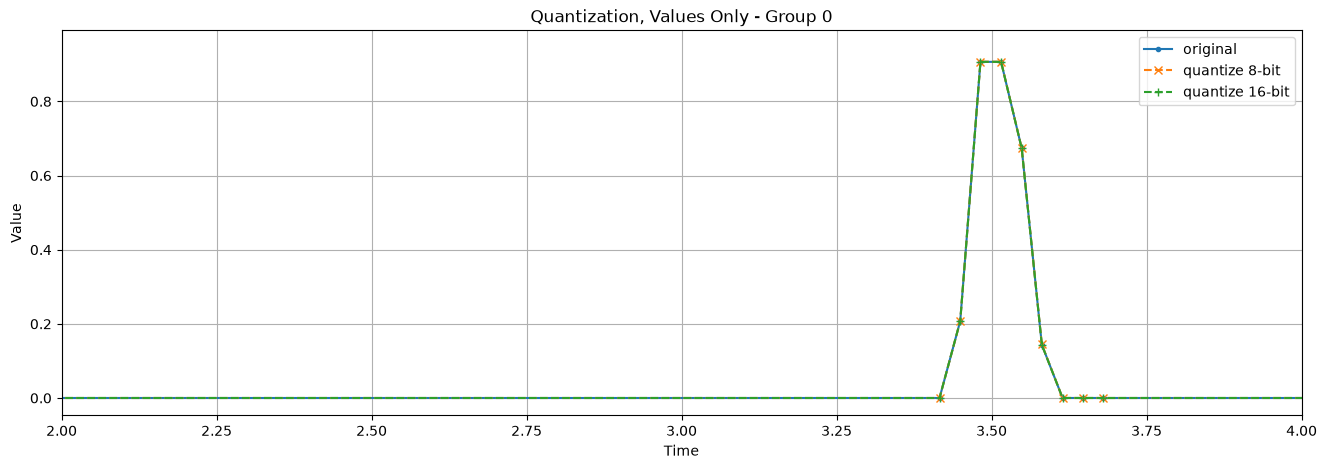

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

codes8 , scale8 , zero8  = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
codes16, scale16, zero16 = quantize(unique_data[group_idx]["values"], q_type=np.uint16)
dq_values8  = dequantize(codes8, scale8, zero8)
dq_values16 = dequantize(codes16, scale16, zero16)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(unique_data[group_idx]["times"], dq_values8 , 'x--', label="quantize 8-bit")
ax.plot(unique_data[group_idx]["times"], dq_values16, '+--', label="quantize 16-bit")

ax.set_title(f"Quantization, Values Only - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()

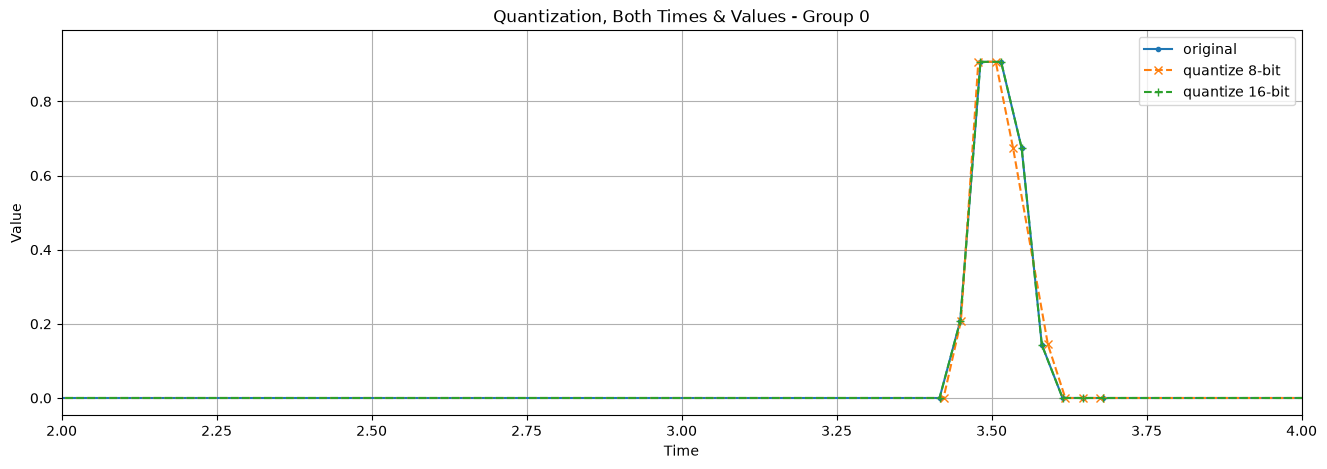

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

v_codes8 , v_scale8 , v_zero8  = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
v_codes16, v_scale16, v_zero16 = quantize(unique_data[group_idx]["values"], q_type=np.uint16)
t_codes8 , t_scale8 , t_zero8  = quantize(unique_data[group_idx]["times"], q_type=np.uint8)
t_codes16, t_scale16, t_zero16 = quantize(unique_data[group_idx]["times"], q_type=np.uint16)

dq_values8  = dequantize(v_codes8 , v_scale8 , v_zero8)
dq_values16 = dequantize(v_codes16, v_scale16, v_zero16)
dq_times8  = dequantize(t_codes8 , t_scale8 , t_zero8)
dq_times16 = dequantize(t_codes16, t_scale16, t_zero16)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(dq_times8 , dq_values8 , 'x--', label="quantize 8-bit")
ax.plot(dq_times16, dq_values16, '+--', label="quantize 16-bit")

ax.set_title(f"Quantization, Both Times & Values - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()

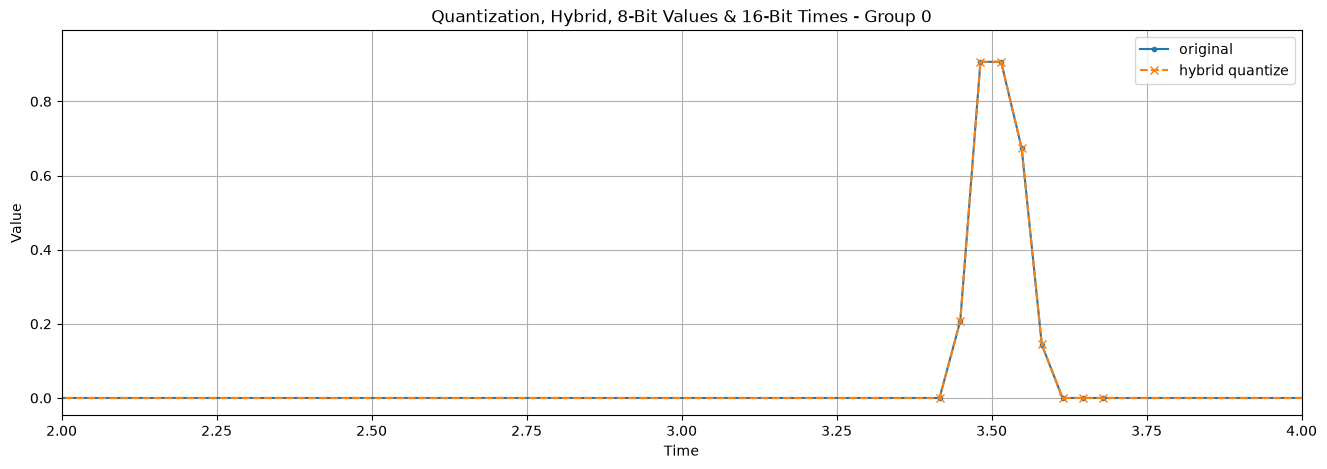

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

v_codes, v_scale, v_zero = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
t_codes, t_scale, t_zero = quantize(unique_data[group_idx]["times"] , q_type=np.uint16)

dq_values = dequantize(v_codes, v_scale, v_zero)
dq_times  = dequantize(t_codes, t_scale, t_zero)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(dq_times, dq_values , 'x--', label="hybrid quantize")

ax.set_title(f"Quantization, Hybrid, 8-Bit Values & 16-Bit Times - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()

---
## Framing

In [45]:
fps = 120
duration = original_clip["animationClip"]["duration"]
num_frames = np.ceil(fps * duration).astype(int)
print("num frame:", num_frames, ", require", np.ceil(np.log2(num_frames)).astype(int), "bits")

num frame: 859 , require 10 bits


In [46]:
2**16 / fps # maximum duration for 16-bit frame encoding

546.1333333333333

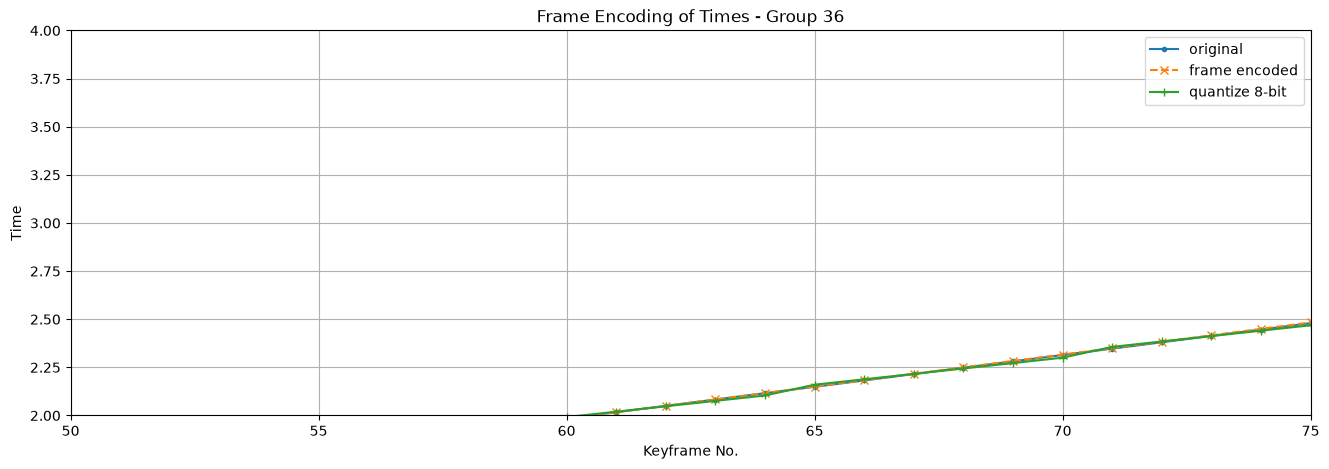

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 36

frame_idx = np.round(np.array(unique_data[group_idx]["times"]) * fps).astype(int)
decode_times = frame_idx / fps

t_codes, t_scale, t_zero = quantize(unique_data[group_idx]["times"] , q_type=np.uint8)
dq_times  = dequantize(t_codes, t_scale, t_zero)

ax.plot(unique_data[group_idx]["times"], '.-', label="original")
ax.plot(decode_times, 'x--', label="frame encoded")
ax.plot(dq_times, '+-', label="quantize 8-bit")

ax.set_title(f"Frame Encoding of Times - Group {group_idx}")
ax.set_xlabel("Keyframe No.")
ax.set_ylabel("Time")
ax.set_xbound(50, 75)
ax.set_ybound(2, 4)
ax.legend()
ax.grid()
plt.show()

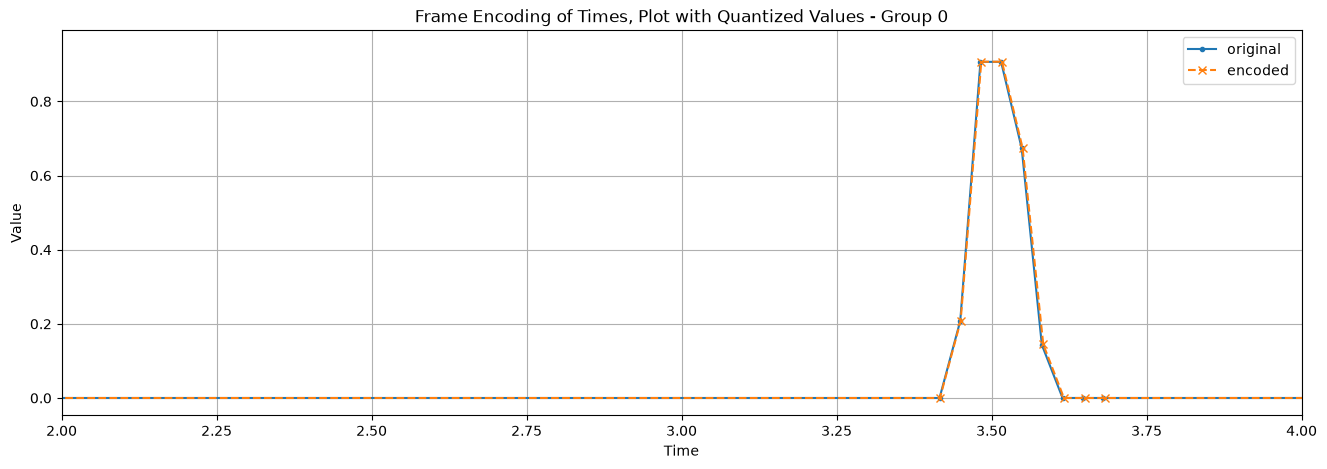

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

v_codes, v_scale, v_zero = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
dq_values = dequantize(v_codes, v_scale, v_zero)

frame_idx = np.round(np.array(unique_data[group_idx]["times"]) * fps).astype(int)
decode_times = frame_idx / fps

dq_times  = dequantize(t_codes, t_scale, t_zero)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(decode_times, dq_values, 'x--', label="encoded")

ax.set_title(f"Frame Encoding of Times, Plot with Quantized Values - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()